## Simulación de un sistema mimo

$$
G(s)=\left[\begin{array}{ll}
G_{11}(s) & G_{12}(s) \\
G_{21}(s) & G_{22}(s)
\end{array}\right]
$$

# 1. Introducción

En prácticas anteriores se identificó experimentalmente un sistema térmico usando modelos de primer orden con tiempo muerto, conocidos como modelos FOPDT:

$$
G(s)=\dfrac{K}{\tau s + 1} e^{-\theta s} \quad (1)
$$

donde:
- $K$ es la ganancia estática,
- $\tau$ es la constante de tiempo,
- $\theta$ es el tiempo muerto.

En el laboratorio se trabajó inicialmente el sistema como un problema SISO (Single Input Single Output). Sin embargo, el sistema térmico real posee dos calentadores y dos sensores de temperatura, por lo que corresponde a un sistema MIMO (Multiple Input Multiple Output).

El sistema puede representarse mediante la siguiente matriz de funciones de transferencia:

$$
\begin{bmatrix}
T_1(s)\\
T_2(s)
\end{bmatrix} = \begin{bmatrix}
G_{11}(s) & G_{12}(s) \\
G_{21}(s) & G_{22}(s)
\end{bmatrix} \begin{bmatrix}
Q_1(s) \\
Q_2(s)
\end{bmatrix} \quad (2)
$$

donde $Q_1(s),Q_2(s)$ representan las señales de los calentadores y $T_1(s),T_2(s)$ las temperaturas medidas. Cada término $G_{ij}(s)$ modela la influencia de una entrada sobre una salida:

$$
G_{ij}(s)=\dfrac{K_{ij}}{\tau_{ij}s+1} e^{-\theta_{ij}s} \quad (3)
$$

En sistemas térmicos reales existe transferencia de calor entre ambas zonas, por lo que un calentador puede afectar las dos temperaturas simultáneamente.

## 2. Objetivos

### 2.1 Objetivo general

Diseñar e implementar una estrategia de control descentralizado para un sistema térmico MIMO utilizando modelos FOPDT identificados experimentalmente y un desacoplador estático.

### 2.2 Objetivos específicos

1. Identificar experimentalmente la matriz de funciones de transferencia del sistema térmico.
2. Analizar el efecto del acoplamiento térmico entre canales.
3. Comprender el concepto de desacoplo en sistemas MIMO.
4. Diseñar un desacoplador estático basado en ganancias estacionarias.
5. Implementar controladores PID para el sistema desacoplado.
6. Comparar el desempeño del sistema con y sin desacoplador.

## 3. Parte A: Identificación Experimental del Sistema MIMO

### 3.1 Experimento 1
Aplicar un escalón en el calentador 1:

$$
Q_1(t)=60\% \quad (4)
$$

$$
Q_2(t)=0\% \quad (5)
$$

Registrar:
$$
T_1(t),\; T_2(t) \quad (6)
$$

A partir de este experimento deben identificarse:

$$
G_{11}(s)=\dfrac{T_1(s)}{Q_1(s)} \quad (7)
$$

$$
G_{21}(s)=\dfrac{T_2(s)}{Q_1(s)} \quad (8)
$$

### 3.2 Experimento 2
Aplicar un escalón en el calentador 2:

$$
Q_2(t)=60\% \quad (9)
$$

$$
Q_1(t)=0\% \quad (10)
$$

Registrar:
$$
T_1(t),\; T_2(t) \quad (11)
$$

A partir de este experimento deben identificarse:

$$
G_{12}(s)=\dfrac{T_1(s)}{Q_2(s)} \quad (12)
$$

$$
G_{22}(s)=\dfrac{T_2(s)}{Q_2(s)} \quad (13)
$$

## 4. Parte B: Construcción del Modelo MIMO

Una vez identificados los cuatro modelos FOPDT, construir la matriz:

$$
G(s)=\begin{bmatrix}
G_{11}(s) & G_{12}(s) \\
G_{21}(s) & G_{22}(s)
\end{bmatrix} \quad (14)
$$

con cada elemento de la forma (Ecuación 15):

$$
G_{ij}(s)=\dfrac{K_{ij}}{\tau_{ij}s+1} e^{-\theta_{ij}s} \quad (15)
$$

## 5. Parte C: Análisis del Acoplamiento

En un sistema idealmente desacoplado se esperaría:

$$
Q_1 \rightarrow T_1 \quad (16)
$$

$$
Q_2 \rightarrow T_2 \quad (17)
$$

Sin embargo, en la práctica existe transferencia de calor entre las zonas, por lo que:

$$
G_{12}(s) \neq 0 \quad (18)
$$

$$
G_{21}(s) \neq 0 \quad (19)
$$

Esto indica que el sistema está acoplado y que se necesita una estrategia para reducir la interacción.

## 6. Parte D: Concepto de Desacoplador

Un desacoplador modifica las señales de control antes de aplicarlas al sistema, buscando reducir el efecto cruzado entre canales. En lugar de aplicar directamente:

$$
\begin{bmatrix}
Q_1(s) \\
Q_2(s)
\end{bmatrix}
$$

se definen entradas virtuales:

$$
\begin{bmatrix}
V_1(s) \\
V_2(s)
\end{bmatrix}
$$

y se utiliza:

$$
\begin{bmatrix}
Q_1(s) \\
Q_2(s)
\end{bmatrix} = D \begin{bmatrix}
V_1(s) \\
V_2(s)
\end{bmatrix} \quad (22)
$$

donde la matriz desacopladora tiene la estructura:

$$
D = \begin{bmatrix}
1 & d_{12} \\
d_{21} & 1
\end{bmatrix} \quad (23)
$$

## 7. Parte E: Diseño del Desacoplador

Usando las ganancias estacionarias definidas como:

$$
G(0)=\begin{bmatrix}
K_{11} & K_{12} \\
K_{21} & K_{22}
\end{bmatrix} \quad (24)
$$

se busca que $G(0)D$ sea aproximadamente diagonal. Realizando la multiplicación:

$$
G(0)D = \begin{bmatrix}
K_{11} + K_{12}d_{21} & K_{11}d_{12} + K_{12} \\
K_{21} + K_{22}d_{21} & K_{21}d_{12} + K_{22}
\end{bmatrix} \quad (26)
$$

Para anular los términos fuera de la diagonal se fuerza:

$$
K_{11}d_{12} + K_{12} = 0 \quad \Rightarrow \quad d_{12} = -\dfrac{K_{12}}{K_{11}} \quad (29)
$$

$$
K_{21} + K_{22}d_{21} = 0 \quad \Rightarrow \quad d_{21} = -\dfrac{K_{21}}{K_{22}} \quad (30)
$$

Finalmente:

$$
D = \begin{bmatrix}
1 & -\dfrac{K_{12}}{K_{11}} \\
-\dfrac{K_{21}}{K_{22}} & 1
\end{bmatrix} \quad (31)
$$

## 8. Parte F: Diseño PID

Diseñar dos controladores PID independientes:

$$
C_1(s) \quad (32) \\
C_2(s) \quad (33)
$$

de la forma paralela:

$$
C_i(s) = K_{p,i} + \dfrac{K_{i,i}}{s} + K_{d,i} s \quad (34)
$$

## 9. Parte G: Comparación Experimental

Comparar los siguientes casos:

### 9.1 Caso 1: Sin desacoplador

Aplicar los controladores directamente sobre la planta MIMO:

$$
Q_1(s)=V_1(s) \quad (35)
$$

$$
Q_2(s)=V_2(s) \quad (36)
$$

### 9.2 Caso 2: Con desacoplador

Introducir la matriz desacopladora $D$ entre los controladores y la planta:

$$
Q_1(s)=V_1(s) + d_{12}V_2(s) \quad (37)
$$

$$
Q_2(s)=d_{21}V_1(s) + V_2(s) \quad (38)
$$

Comparar:
- Tiempo de establecimiento (Ts).
- Sobreimpulso (%OS).
- Error estacionario (ess).
- Interacción entre canales.
- Esfuerzo de control.

---

(La siguiente sección del notebook implementa la identificación, el diseño del desacoplador y la simulación numérica para los casos 9.1 y 9.2.)

In [3]:
%pip install control pandas
import numpy as np
import matplotlib.pyplot as plt
import control as ct
import pandas as pd
from scipy.linalg import block_diag
from scipy.optimize import fsolve
s = ct.TransferFunction.s

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 24.0 MB/s  0:00:00m0:00:010:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 3. Parte A: Identificación Experimental del Sistema MIMO

### 3.1 Experimento 1
Aplicar un escalón en el calentador 1:

$$
Q_1(t)=60\% \quad (4)
$$

$$
Q_2(t)=0\% \quad (5)
$$

Registrar:
$$
T_1(t),\; T_2(t) \quad (6)
$$

A partir de este experimento deben identificarse:

$$
G_{11}(s)=\dfrac{T_1(s)}{Q_1(s)} \quad (7)
$$

$$
G_{21}(s)=\dfrac{T_2(s)}{Q_1(s)} \quad (8)
$$

### 3.2 Experimento 2
Aplicar un escalón en el calentador 2:

$$
Q_2(t)=60\% \quad (9)
$$

$$
Q_1(t)=0\% \quad (10)
$$

Registrar:
$$
T_1(t),\; T_2(t) \quad (11)
$$

A partir de este experimento deben identificarse:

$$
G_{12}(s)=\dfrac{T_1(s)}{Q_2(s)} \quad (12)
$$

$$
G_{22}(s)=\dfrac{T_2(s)}{Q_2(s)} \quad (13)
$$


In [ ]:
# Lectura y graficas de data_Q1.txt y data_Q2.txt en la misma celda

# -----------------------------
# data_Q1.txt
# -----------------------------
ruta_q1 = "data_Q1.txt"
data_q1 = np.genfromtxt(ruta_q1, delimiter=",", skip_header=1, encoding="latin1")

tiempo_q1 = data_q1[:, 0]
temp1_q1 = data_q1[:, 3]
temp2_q1 = data_q1[:, 4]

# -----------------------------
# data_Q2.txt
# -----------------------------
ruta_q2 = "data_Q2.txt"
data_q2 = np.genfromtxt(ruta_q2, delimiter=",", skip_header=1, encoding="latin1")

tiempo_q2 = data_q2[:, 0]
temp1_q2 = data_q2[:, 3]
temp2_q2 = data_q2[:, 4]

# -----------------------------
# Grafica comparativa lado a lado
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5))

ax1.plot(tiempo_q1, temp1_q1, color="#1f77b4", linewidth=2, label="Temp1 G11")
ax1.plot(tiempo_q1, temp2_q1, color="#ff7f0e", linewidth=2, label="Temp2 G21")
ax1.set_title("Lectura de data_Q1.txt")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Temperatura [°C]")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(tiempo_q2, temp1_q2, color="#1f77b4", linewidth=2, label="Temp1 G12")
ax2.plot(tiempo_q2, temp2_q2, color="#ff7f0e", linewidth=2, label="Temp2 G22")
ax2.set_title("Lectura de data_Q2.txt")
ax2.set_xlabel("Tiempo [s]")
ax2.set_ylabel("Temperatura [°C]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()



A partir de este experimento se identifico:

$$
G_{11}(s)=\dfrac{T_1(s)}{Q_1(s)} \quad (7)
$$

$$
G_{21}(s)=\dfrac{T_2(s)}{Q_1(s)} \quad (8)
$$

$$
G_{12}(s)=\dfrac{T_1(s)}{Q_2(s)} \quad (12)
$$

$$
G_{22}(s)=\dfrac{T_2(s)}{Q_2(s)} \quad (13)
$$


In [ ]:
# ==========================================================
# SELECCIÓN DEL MÉTODO
# ==========================================================

metodo = "Opt"      # "ZN", "Smith", "Opt"

# ==========================================================
# BASE DE MODELOS
# ==========================================================

modelos = {

    "ZN": {

        "G11": {
            "K": 0.327137,
            "tau": 66.940388,
            "theta": 11.376236
        },

        "G21": {
            "K": 4.740750,
            "tau": 52.885263,
            "theta": 264.278912
        },

        "G12": {
             "K": 0.232723,
           #"K": 6.957350,
           #"K": 0.3271,
            "tau": 61.258527,
            #"tau": 61.044876,
            #"tau": 66.9404,
            "theta": 97.457519
            #"theta": 107.675990
            #"theta": 11.3762
        },

        "G22": {
            "K": 0.293100,
            "tau": 60.038800,
            "theta": 38.969049
        }
    },

    "Smith": {

        "G11": {
            "K": 0.327137,
            "tau": 110.666585,
            "theta": 11.376236
        },

        "G21": {
            "K": 4.740750,
            "tau": 0.000001,
            "theta": 264.278912
        },

        "G12": {
            "K": 0.232723,
            #"K": 6.957350,
            "tau": 88.607912,
            #"tau": 88.394262,
            #"tau": 184.6940,
            "theta": 97.457519
            #"theta": 11.3762
        },

        "G22": {
            "K": 0.293100,
            "tau": 98.079754,
            "theta": 38.969049
        }
    },

    "Opt": {

        "G11": {
            "K": 0.351739,
            "tau": 133.970231,
            "theta": 5.702262
        },

        "G21": {
            "K": 4.228404,
            "tau": 0.000002,
            "theta": 264.278912
        },

        "G12": {
            "K": 0.343572,
             #"K": 10.219315,
            #"K": 10.219315,
            "tau": 269.325014,
            #"tau": 266.019361,
            #"tau": 266.0185,
            "theta": 36.458855
            #"theta": 47.5783
        },

        "G22": {
            "K": 0.326119,
            "tau": 145.221583,
            "theta": 15.444018
        }
    }
}

# ==========================================================
# CARGA AUTOMÁTICA
# ==========================================================

K11 = modelos[metodo]["G11"]["K"]
tau_11 = modelos[metodo]["G11"]["tau"]
tm_11 = modelos[metodo]["G11"]["theta"]

K21 = modelos[metodo]["G21"]["K"]
tau_21 = modelos[metodo]["G21"]["tau"]
tm_21 = modelos[metodo]["G21"]["theta"]

K12 = modelos[metodo]["G12"]["K"]
tau_12 = modelos[metodo]["G12"]["tau"]
tm_12 = modelos[metodo]["G12"]["theta"]

K22 = modelos[metodo]["G22"]["K"]
tau_22 = modelos[metodo]["G22"]["tau"]
tm_22 = modelos[metodo]["G22"]["theta"]

# ==========================================================
# VERIFICACIÓN
# ==========================================================

print(f"Método seleccionado: {metodo}")

print("\nG11")
print(K11, tau_11, tm_11)

print("\nG12")
print(K12, tau_12, tm_12)

print("\nG21")
print(K21, tau_21, tm_21)

print("\nG22")
print(K22, tau_22, tm_22)

In [ ]:
# Graficas comparativas de los cuatro elementos de la matriz MIMO

metodos_cmp = ["ZN", "Smith", "Opt"]
colores = {"ZN": "#1f77b4", "Smith": "#ff7f0e", "Opt": "#2ca02c"}
etiquetas = {"ZN": "Ziegler-Nichols", "Smith": "Smith", "Opt": "Optimizacion"}


def planta_fopdt(k, tau, theta):
    num_delay, den_delay = ct.pade(theta, 1)
    delay = ct.tf(num_delay, den_delay)
    return (k / (tau * s + 1)) * delay


plantas = {
    "G11": {m: planta_fopdt(modelos[m]["G11"]["K"], modelos[m]["G11"]["tau"], modelos[m]["G11"]["theta"]) for m in metodos_cmp},
    "G21": {m: planta_fopdt(modelos[m]["G21"]["K"], modelos[m]["G21"]["tau"], modelos[m]["G21"]["theta"]) for m in metodos_cmp},
    "G12": {m: planta_fopdt(modelos[m]["G12"]["K"], modelos[m]["G12"]["tau"], modelos[m]["G12"]["theta"]) for m in metodos_cmp},
    "G22": {m: planta_fopdt(modelos[m]["G22"]["K"], modelos[m]["G22"]["tau"], modelos[m]["G22"]["theta"]) for m in metodos_cmp},
}

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
fig.suptitle("Comparacion de respuestas FOPDT: Ziegler-Nichols vs Smith vs Optimizacion", fontsize=16, fontweight="bold")

ejes = {
    "G11": axs[0, 0],
    "G21": axs[0, 1],
    "G12": axs[1, 0],
    "G22": axs[1, 1],
}

t = np.linspace(0, 1000, 2000)

for nombre, ax in ejes.items():
    for metodo_cmp in metodos_cmp:
        sistema = plantas[nombre][metodo_cmp]
        _, respuesta = ct.step_response(sistema, t)
        ax.plot(t, respuesta, label=etiquetas[metodo_cmp], color=colores[metodo_cmp], linewidth=2)
    ax.set_title(nombre)
    ax.set_xlabel("Tiempo [s]")
    ax.set_ylabel("Temperatura relativa [°C]")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# Comparacion de G11, G21, G12 y G22 con sus datos experimentales

# -----------------------------
# Datos experimentales
# -----------------------------
ruta_q1 = "data_Q1.txt"
data_q1 = np.genfromtxt(ruta_q1, delimiter=",", skip_header=1, encoding="latin1")
tiempo_q1 = data_q1[:, 0]
temp1_q1 = data_q1[:, 3]
temp2_q1 = data_q1[:, 4]

temp1_q1_rel = temp1_q1 - temp1_q1[0]
temp2_q1_rel = temp2_q1 - temp2_q1[0]

ruta_q2 = "data_Q2.txt"
data_q2 = np.genfromtxt(ruta_q2, delimiter=",", skip_header=1, encoding="latin1")
tiempo_q2 = data_q2[:, 0]
temp1_q2 = data_q2[:, 3]
temp2_q2 = data_q2[:, 4]

temp1_q2_rel = temp1_q2 - temp1_q2[0]
temp2_q2_rel = temp2_q2 - temp2_q2[0]

# Tiempos uniformes para las respuestas del modelo
# step_response requiere puntos de tiempo igualmente espaciados.
t_modelo_q1 = np.linspace(tiempo_q1[0], tiempo_q1[-1], len(tiempo_q1))
t_modelo_q2 = np.linspace(tiempo_q2[0], tiempo_q2[-1], len(tiempo_q2))

# -----------------------------
# Modelos FOPDT por metodo
# -----------------------------
def planta_fopdt(k, tau, theta):
    num_delay, den_delay = ct.pade(theta, 1)
    delay = ct.tf(num_delay, den_delay)
    return (k / (tau * s + 1)) * delay

plantas = {
    "G11": {m: planta_fopdt(modelos[m]["G11"]["K"], modelos[m]["G11"]["tau"], modelos[m]["G11"]["theta"]) for m in metodos_cmp},
    "G21": {m: planta_fopdt(modelos[m]["G21"]["K"], modelos[m]["G21"]["tau"], modelos[m]["G21"]["theta"]) for m in metodos_cmp},
    "G12": {m: planta_fopdt(modelos[m]["G12"]["K"], modelos[m]["G12"]["tau"], modelos[m]["G12"]["theta"]) for m in metodos_cmp},
    "G22": {m: planta_fopdt(modelos[m]["G22"]["K"], modelos[m]["G22"]["tau"], modelos[m]["G22"]["theta"]) for m in metodos_cmp},
}


def etiqueta_modelo(nombre_modelo, metodo_cmp):
    parametros = modelos[metodo_cmp][nombre_modelo]
    return f"{etiquetas[metodo_cmp]} ({nombre_modelo}: K={parametros['K']:.4f}, tau={parametros['tau']:.4f}, theta={parametros['theta']:.4f})"


def escalar_respuesta(respuesta, referencia):
    if np.isclose(respuesta[-1], 0):
        return respuesta
    return respuesta * (referencia[-1] / respuesta[-1])


# -----------------------------
# Grafica comparativa con datos experimentales
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
fig.suptitle("Comparacion de modelos FOPDT y datos experimentales", fontsize=16, fontweight="bold")

# G11: comparar con Temp1 G11
ax = axs[0, 0]
_, respuesta = ct.step_response(plantas["G11"]["ZN"], t_modelo_q1)
respuesta = escalar_respuesta(respuesta, temp1_q1_rel)
ax.plot(t_modelo_q1, respuesta, label=etiqueta_modelo("G11", "ZN"), color="#1f77b4", linewidth=2)
_, respuesta = ct.step_response(plantas["G11"]["Smith"], t_modelo_q1)
respuesta = escalar_respuesta(respuesta, temp1_q1_rel)
ax.plot(t_modelo_q1, respuesta, label=etiqueta_modelo("G11", "Smith"), color="#ff7f0e", linewidth=2)
_, respuesta = ct.step_response(plantas["G11"]["Opt"], t_modelo_q1)
respuesta = escalar_respuesta(respuesta, temp1_q1_rel)
ax.plot(t_modelo_q1, respuesta, label=etiqueta_modelo("G11", "Opt"), color="#2ca02c", linewidth=2)
ax.plot(tiempo_q1, temp1_q1_rel, label="Temp1 experimental en Q1", color="#000000", linewidth=2, linestyle="--")
ax.set_title("G11 vs Temp1 en Q1")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Temperatura relativa [°C]")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(t_modelo_q1[0], t_modelo_q1[-1])

# G21: comparar con Temp2 G21
ax = axs[0, 1]
_, respuesta = ct.step_response(plantas["G21"]["ZN"], t_modelo_q1)
respuesta = escalar_respuesta(respuesta, temp2_q1_rel)
ax.plot(t_modelo_q1, respuesta, label=etiqueta_modelo("G21", "ZN"), color="#1f77b4", linewidth=2)
_, respuesta = ct.step_response(plantas["G21"]["Smith"], t_modelo_q1)
respuesta = escalar_respuesta(respuesta, temp2_q1_rel)
ax.plot(t_modelo_q1, respuesta, label=etiqueta_modelo("G21", "Smith"), color="#ff7f0e", linewidth=2)
_, respuesta = ct.step_response(plantas["G21"]["Opt"], t_modelo_q1)
respuesta = escalar_respuesta(respuesta, temp2_q1_rel)
ax.plot(t_modelo_q1, respuesta, label=etiqueta_modelo("G21", "Opt"), color="#2ca02c", linewidth=2)
ax.plot(tiempo_q1, temp2_q1_rel, label="Temp2 experimental en Q1", color="#000000", linewidth=2, linestyle="--")
ax.set_title("G21 vs Temp2 en Q1")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Temperatura relativa [°C]")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(t_modelo_q1[0], t_modelo_q1[-1])

# G12: comparar con Temp1 G12
ax = axs[1, 0]
_, respuesta = ct.step_response(plantas["G12"]["ZN"], t_modelo_q2)
respuesta = escalar_respuesta(respuesta, temp1_q2_rel)
ax.plot(t_modelo_q2, respuesta, label=etiqueta_modelo("G12", "ZN"), color="#1f77b4", linewidth=2)
_, respuesta = ct.step_response(plantas["G12"]["Smith"], t_modelo_q2)
respuesta = escalar_respuesta(respuesta, temp1_q2_rel)
ax.plot(t_modelo_q2, respuesta, label=etiqueta_modelo("G12", "Smith"), color="#ff7f0e", linewidth=2)
_, respuesta = ct.step_response(plantas["G12"]["Opt"], t_modelo_q2)
respuesta = escalar_respuesta(respuesta, temp1_q2_rel)
ax.plot(t_modelo_q2, respuesta, label=etiqueta_modelo("G12", "Opt"), color="#2ca02c", linewidth=2)
ax.plot(tiempo_q2, temp1_q2_rel, label="Temp1 experimental en Q2", color="#000000", linewidth=2, linestyle="--")
ax.set_title("G12 vs Temp1 en Q2")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Temperatura relativa [°C]")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(t_modelo_q2[0], t_modelo_q2[-1])

# G22: comparar con Temp2 G22
ax = axs[1, 1]
_, respuesta = ct.step_response(plantas["G22"]["ZN"], t_modelo_q2)
respuesta = escalar_respuesta(respuesta, temp2_q2_rel)
ax.plot(t_modelo_q2, respuesta, label=etiqueta_modelo("G22", "ZN"), color="#1f77b4", linewidth=2)
_, respuesta = ct.step_response(plantas["G22"]["Smith"], t_modelo_q2)
respuesta = escalar_respuesta(respuesta, temp2_q2_rel)
ax.plot(t_modelo_q2, respuesta, label=etiqueta_modelo("G22", "Smith"), color="#ff7f0e", linewidth=2)
_, respuesta = ct.step_response(plantas["G22"]["Opt"], t_modelo_q2)
respuesta = escalar_respuesta(respuesta, temp2_q2_rel)
ax.plot(t_modelo_q2, respuesta, label=etiqueta_modelo("G22", "Opt"), color="#2ca02c", linewidth=2)
ax.plot(tiempo_q2, temp2_q2_rel, label="Temp2 experimental en Q2", color="#000000", linewidth=2, linestyle="--")
ax.set_title("G22 vs Temp2 en Q2")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Temperatura relativa [°C]")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(t_modelo_q2[0], t_modelo_q2[-1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

ModuleNotFoundError: No module named 'numpy'

## Interpretación del modelo

Si se toma `Q_i(t)` como la entrada y `T_j(t)` como la salida, entonces el modelo asociado a cualquier canal del sistema queda escrito en el dominio de Laplace como:

$$G_{ij}(s)=\frac{T_j(s)}{Q_i(s)} \approx \frac{K_{ij} e^{-\theta_{ij}s}}{\tau_{ij}s + 1}$$

Aquí `Q_i(s)` y `T_j(s)` son las transformadas de Laplace de las señales en el tiempo. Esta es la forma general de la matriz MIMO; por ejemplo, `G11(s)` es el caso particular cuando $i=1$ y $j=1$.

No se trata del dominio de frecuencia en sentido estricto; la interpretación de frecuencia aparece después, si se evalúa el modelo en $s=j\omega$.

In [ ]:
# Construcción de G11(s), G12(s), G21(s) y G22(s) con los parámetros del método seleccionado
# Gij(s) = Kij * e^(-theta_ij s) / (tau_ij s + 1)

s = ct.TransferFunction.s

def fopdt(k, tau, theta):
    num_delay, den_delay = ct.pade(theta, 1)
    delay = ct.tf(num_delay, den_delay)
    return (k / (tau*s + 1)) * delay

G11 = fopdt(K11, tau_11, tm_11)
G12 = fopdt(K12, tau_12, tm_12)
G21 = fopdt(K21, tau_21, tm_21)
G22 = fopdt(K22, tau_22, tm_22)

print("G11(s) =")
print(G11)
print("\nG12(s) =")
print(G12)
print("\nG21(s) =")
print(G21)
print("\nG22(s) =")
print(G22)

<TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.3271
  ---------
  159 s + 1
<TransferFunction>: sys[11]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.2327
  -----------
  228.8 s + 1
<TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.2931
  ---------
  169 s + 1
<TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.1573
  -----------
  232.3 s + 1


4. Parte B: Construcción del Modelo MIMO

Una vez identificados los cuatro modelos FOPDT, construir la matriz:

$$
G(s) =
\begin{bmatrix}
G_{11}(s) & G_{12}(s) \\
G_{21}(s) & G_{22}(s)
\end{bmatrix}
$$

(14)

In [8]:
G_mimo = ct.tf([[G11,G12],
                [G21,G22]])
print(G_mimo)

<TransferFunction>: sys[24]
Inputs (2): ['u[0]', 'u[1]']
Outputs (2): ['y[0]', 'y[1]']

Input 1 to output 1:

   0.3271
  ---------
  159 s + 1

Input 1 to output 2:

    0.1573
  -----------
  232.3 s + 1

Input 2 to output 1:

    0.2327
  -----------
  228.8 s + 1

Input 2 to output 2:

   0.2931
  ---------
  169 s + 1


In [ ]:
# Preparar datos experimentales y tiempos uniformes
import numpy as np

# Leer archivos (ruta relativa al notebook)
data_q1 = np.genfromtxt('mimo/mimoLector/data_Q1.txt', delimiter=',', skip_header=1, encoding='latin1')
t_q1 = data_q1[:,0]
temp1_q1 = data_q1[:,3]
temp2_q1 = data_q1[:,4]

# Temperaturas relativas (restar valor inicial)
temp1_q1_rel = temp1_q1 - temp1_q1[0]
temp2_q1_rel = temp2_q1 - temp2_q1[0]

# Tiempo uniforme para simulaciones del modelo (mismo número de muestras que la señal experimental)
t_model_q1 = np.linspace(t_q1[0], t_q1[-1], len(t_q1))

# Q2
try:
    data_q2 = np.genfromtxt('mimo/mimoLector/data_Q2.txt', delimiter=',', skip_header=1, encoding='latin1')
    t_q2 = data_q2[:,0]
    temp1_q2 = data_q2[:,3]
    temp2_q2 = data_q2[:,4]
    temp1_q2_rel = temp1_q2 - temp1_q2[0]
    temp2_q2_rel = temp2_q2 - temp2_q2[0]
    t_model_q2 = np.linspace(t_q2[0], t_q2[-1], len(t_q2))
except Exception as e:
    print('No se pudo leer data_Q2.txt:', e)
    t_q2 = np.array([])
    temp1_q2_rel = np.array([])
    temp2_q2_rel = np.array([])
    t_model_q2 = np.array([])

# Función para escalar la respuesta del modelo a la variación experimental
def scale_to_exp(y_model, y_exp):
    dy_model = y_model[-1] - y_model[0]
    dy_exp = y_exp[-1] - y_exp[0]
    if np.isclose(dy_model, 0):
        return y_model
    return y_model * (dy_exp / dy_model)

print('Datos Q1:', t_q1.shape, temp1_q1_rel.shape, temp2_q1_rel.shape)
print('Tiempos modelo Q1/Q2:', t_model_q1.shape, t_model_q2.shape)

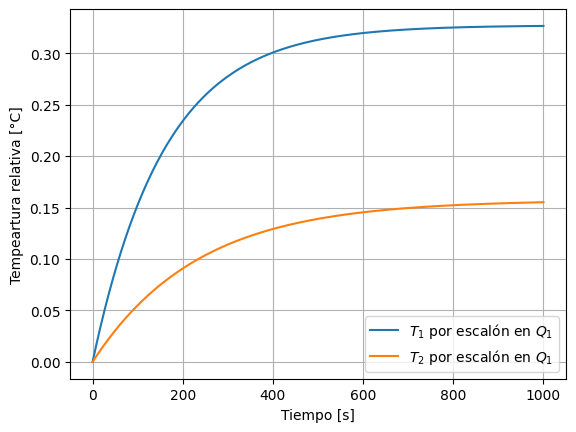

In [ ]:
# Simulación modelo para escalón en Q1 (usar tiempo uniforme de Q1)
t = t_model_q1

t1, y11 = ct.step_response(G11, t)
t1, y21 = ct.step_response(G21, t)

# Escalar a la variación experimental
try:
    y11s = scale_to_exp(y11, temp1_q1_rel)
    y21s = scale_to_exp(y21, temp2_q1_rel)
except NameError:
    y11s, y21s = y11, y21

plt.figure(figsize=(9, 4.5))
plt.plot(t1, y11s, label=r"$T_1$ modelo por escalón en $Q_1$ (G11)")
plt.plot(t1, y21s, label=r"$T_2$ modelo por escalón en $Q_1$ (G21)")
# Superponer datos experimentales
plt.plot(t_q1, temp1_q1_rel, 'k--', label=r"$T_1$ experimental en $Q_1$")
plt.plot(t_q1, temp2_q1_rel, 'k:', label=r"$T_2$ experimental en $Q_1$")
plt.title("Respuesta al escalón en $Q_1$: modelo vs experimento")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Temperatura relativa [°C]")
plt.legend()
plt.tight_layout()
plt.show()

## Nota para interpretar la gráfica de G21

Si la curva de $T_2$ modelo por escalón en $Q_1$ (G21) se ve casi rectangular, no significa que la planta térmica real tenga una respuesta cuadrada.

En este notebook el método activo es `Opt` y para G21 se está usando un tiempo muerto grande y una constante de tiempo muy pequeña. Esa combinación hace que la salida permanezca casi plana durante el retardo y luego suba muy rápido, por lo que visualmente parece un pulso o un rectángulo.

Lo que debería recordarse al verla es esto:

- antes del tiempo muerto, la salida casi no cambia
- después del tiempo muerto, la subida es muy brusca por el valor pequeño de $\tau$
- para una planta térmica física, una subida más suave y progresiva suele ser más realista

En resumen, la forma rectangular es un efecto del ajuste del modelo, no necesariamente del sistema real.

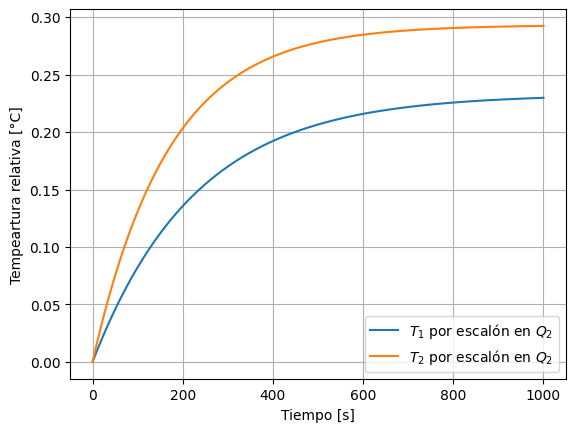

In [ ]:
# Simulación modelo para escalón en Q2 (usar tiempo uniforme de Q2)
if t_model_q2.size > 0:
    t = t_model_q2
    t2, y12 = ct.step_response(G12, t)
    t2, y22 = ct.step_response(G22, t)

    # Escalar a la variación experimental
    try:
        y12s = scale_to_exp(y12, temp1_q2_rel)
        y22s = scale_to_exp(y22, temp2_q2_rel)
    except NameError:
        y12s, y22s = y12, y22

    plt.figure(figsize=(9, 4.5))
    plt.plot(t2, y12s, label=r"$T_1$ modelo por escalón en $Q_2$ (G12)")
    plt.plot(t2, y22s, label=r"$T_2$ modelo por escalón en $Q_2$ (G22)")
    # Superponer datos experimentales
    plt.plot(t_q2, temp1_q2_rel, 'k--', label=r"$T_1$ experimental en $Q_2$")
    plt.plot(t_q2, temp2_q2_rel, 'k:', label=r"$T_2$ experimental en $Q_2$")
    plt.title("Respuesta al escalón en $Q_2$: modelo vs experimento")
    plt.grid(True)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Temperatura relativa [°C]")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No hay datos Q2 cargados.')

## 5. Parte C: Análisis del Acoplamiento

En un sistema idealmente desacoplado se esperaría:

$$
Q_1 \rightarrow T_1 \quad (16)
$$

$$
Q_2 \rightarrow T_2 \quad (17)
$$

Sin embargo, en la práctica existe transferencia de calor entre las zonas, por lo que:

$$
G_{12}(s) \neq 0 \quad (18)
$$

$$
G_{21}(s) \neq 0 \quad (19)
$$

Esto indica que el sistema está acoplado y que se necesita una estrategia para reducir la interacción.


## Simulación de un sistema mimo

$$
G(s)=\left[\begin{array}{ll}
G_{11}(s) & G_{12}(s) \\
G_{21}(s) & G_{22}(s)
\end{array}\right]
$$

## Descripción: Sistema MIMO 2×2

En un sistema MIMO 2×2 con dos señales manipuladas $M_1(s), M_2(s)$ y dos salidas $C_1(s), C_2(s)$ se tiene:

$$
\begin{bmatrix}
T_1(s) \\
T_2(s)
\end{bmatrix} = \begin{bmatrix}
G_{p11}(s) & G_{p12}(s) \\
G_{p21}(s) & G_{p22}(s)
\end{bmatrix} \begin{bmatrix}
Q_1(s) \\
Q_2(s)
\end{bmatrix}
$$

Es decir:

$$
T_1(s)=G_{p11}(s)Q_1(s)+G_{p12}(s)Q_2(s)
$$

$$
T_2(s)=G_{p21}(s)Q_1(s)+G_{p22}(s)Q_2(s)
$$

Los términos $G_{p12}(s)$ y $G_{p21}(s)$ representan las interacciones cruzadas (efecto de una entrada sobre la otra salida). Si las interacciones son relevantes, el diseño SISO independiente puede producir respuestas no deseadas; por eso se emplea un desacoplador o diseño MIMO.

## 2. Idea del desacoplo

El objetivo del desacoplo es introducir compensadores adicionales que reduzcan o eliminen el efecto cruzado entre lazos.

Se definen dos señales generadas directamente por los controladores:

$$
Q_{11}(s) = G_{c1}(s)E_1(s), \tag{4}
$$

$$
Q_{22}(s) = G_{c2}(s)E_2(s). \tag{5}
$$

Luego, se agregan dos desacopladores:

$$
Q_{12}(s) = D_{12}(s)Q_{22}(s), \tag{6}
$$

$$
Q_{21}(s) = D_{21}(s)Q_{11}(s). \tag{7}
$$

Las entradas reales de la planta quedan:

$$
Q_1(s) = Q_{11}(s) + Q_{12}(s), \tag{8}
$$

$$
Q_2(s) = Q_{22}(s) + Q_{21}(s). \tag{9}
$$

Sustituyendo:

$$
Q_1(s) = Q_{11}(s) + D_{12}(s)Q_{22}(s), \tag{10}
$$

$$
Q_2(s) = D_{21}(s)Q_{11}(s) + Q_{22}(s). \tag{11}
$$